In [2]:
import pandas as pd 


In [3]:
df=pd.read_csv("dataset/data.csv",encoding="latin1")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"]

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 541909, dtype: datetime64[us]

In [8]:
len(df['Description'])

541909

In [9]:
len(df['Description'].unique())

4224

ASSUMING:4224 total products in data set

In [10]:
df['Price']=df['UnitPrice']*df["Quantity"]

In [11]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [12]:
Totalsells=df.groupby("Description")["Price"].agg(
    Totalsells="sum"
)

In [13]:
Totalsells.head()

,Totalsells
Description,
4 PURPLE FLOCK DINNER CANDLES,290.80
50'S CHRISTMAS GIFT BAG LARGE,2341.13
DOLLY GIRL BEAKER,2882.50
I LOVE LONDON MINI BACKPACK,1628.17
I LOVE LONDON MINI RUCKSACK,4.15


In [14]:
Totalsells.sort_values(by="Totalsells",ascending=False).head(5)

,Totalsells
Description,
DOTCOM POSTAGE,206245.48
REGENCY CAKESTAND 3 TIER,164762.19
WHITE HANGING HEART T-LIGHT HOLDER,99668.47
PARTY BUNTING,98302.98
JUMBO BAG RED RETROSPOT,92356.03


In [15]:
Totalsells.sort_values(by="Totalsells",ascending=True).head(5)

,Totalsells
Description,
AMAZON FEE,-221520.500
Manual,-68671.640
Adjust bad debt,-11062.060
CRUK Commission,-7933.430
Bank Charges,-7175.639


In [16]:
df[df["UnitPrice"]<0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Price
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06


In [17]:
df[df['UnitPrice'] < 0]['InvoiceNo'].str.startswith('C').all()
#don't follow consistant pattern

np.False_

In [18]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [19]:
df.Country.unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

selling in 38 countries 

In [20]:
TotalRevenue=df.groupby("Country")["Price"].agg(
    TotalRevenue="sum"
)

# top five country with most revenue

In [21]:
TotalRevenue.TotalRevenue.sort_values(ascending=False).head()

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Name: TotalRevenue, dtype: float64

In [22]:
TotalRevenueByYear=df.groupby(["Country",df.InvoiceDate.dt.year])["Price"].agg(
    TotalRevenue="sum"
)

In [23]:
TotalRevenueByYear.head()

TotalRevenue
Country   InvoiceDate              
Australia 2010              1005.10
          2011            136072.17
Austria   2010               257.04
          2011              9897.28
Bahrain   2010               205.74

In [24]:
TotalRevenueByYear.sort_values(by='TotalRevenue',ascending=False).head()

TotalRevenue
Country        InvoiceDate              
United Kingdom 2011          7511063.744
               2010           676742.620
Netherlands    2011           275877.060
EIRE           2011           254246.870
Germany        2011           207135.370

In [28]:
x=TotalRevenueByYear.reset_index()
x[x["InvoiceDate"]==2011].sort_values(by='TotalRevenue',ascending=False).head()

,Country,InvoiceDate,TotalRevenue
59,United Kingdom,2011,7511063.744
40,Netherlands,2011,275877.060
18,EIRE,2011,254246.870
25,Germany,2011,207135.370
23,France,2011,187828.540


In [29]:

x[x["InvoiceDate"]==2010].sort_values(by='TotalRevenue',ascending=False).head()

,Country,InvoiceDate,TotalRevenue
58,United Kingdom,2010,676742.62
24,Germany,2010,14562.84
22,France,2010,9575.36
17,EIRE,2010,9029.95
39,Netherlands,2010,8784.48


In [ ]:
data=TotalRevenueByYear.reset_index()
data=data[data.Country!="United Kingdom"]

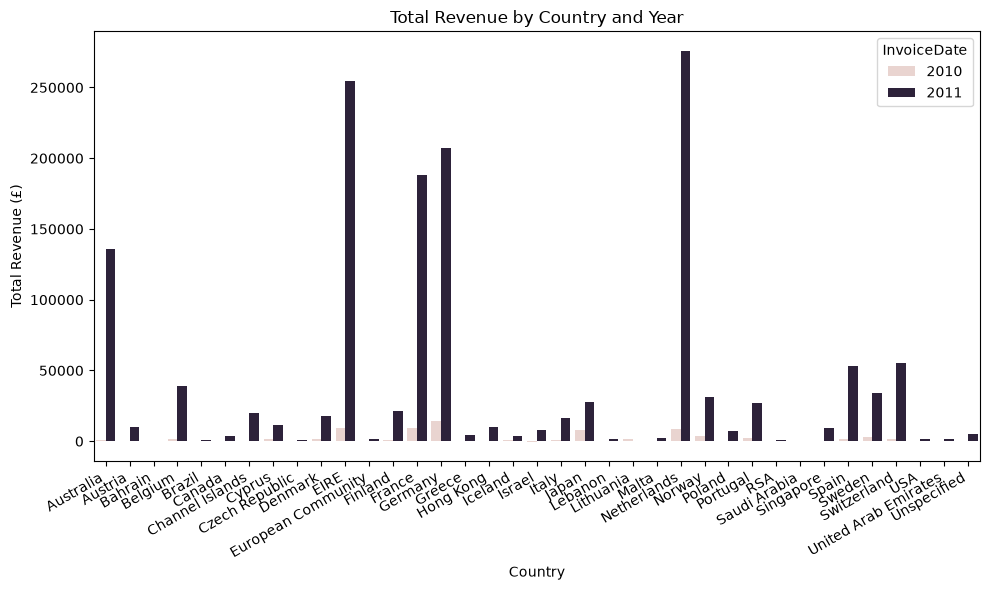

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='Country', y='TotalRevenue', hue='InvoiceDate', dodge=True)
plt.title('Total Revenue by Country and Year')
plt.ylabel('Total Revenue (£)')
plt.xlabel('Country')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
data.head()

,Country,InvoiceDate,TotalRevenue
0,Australia,2010,1005.10
1,Australia,2011,136072.17
2,Austria,2010,257.04
3,Austria,2011,9897.28
4,Bahrain,2010,205.74


In [30]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
